# Feature Analysis

Explore and visualize all features used in this project.

## 0 — Imports

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve().parent))

import matplotlib.pyplot as plt

import symass

## 1 — Load data

In [2]:
FEATURES = ["Z", "N", "Nhw", "C2_3", "C3_3", "C2_4", "C3_4", "C4_4", "T_z"]
TARGETS  = ["BE_total_MeV"]

X, y, N, Z, ame_source = symass.load_data(FEATURES, TARGETS, keep_extrapolated=True)
print(f"Total samples : {len(X)}")
print(f"Feature shape : {X.shape}")
print(f"Target shape  : {y.shape}")

Total samples : 3558
Feature shape : (3558, 9)
Target shape  : (3558, 1)


## 2 — Feature heatmaps on nuclear chart

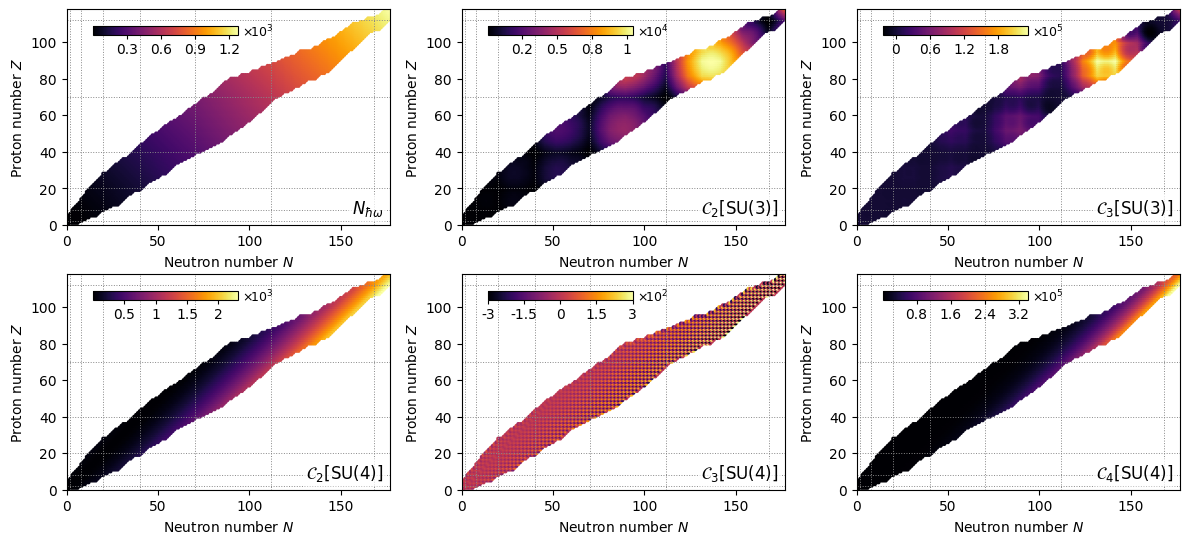

<Figure size 640x480 with 0 Axes>

In [3]:
df = symass.load_dataframe(keep_extrapolated=True)
symass.plot_maps(df, ["Nhw", "C2_3", "C3_3", "C2_4", "C3_4", "C4_4"], cmap="inferno", figsize=(12, 5.5), title_out=False,
                 savefig="figures/SU3SU4_features.png")
plt.tight_layout()
plt.show()

## 2b — Splitting the signed cubic SU(4) Casimir

The cubic Casimir $\mathcal{C}_3[\mathrm{SU}(4)]$ is an **odd** (signed) invariant: it carries
the sign of $(P - P'')$. A simple, *user-side*
feature-engineering trick is to split it into two nonnegative branches,
$\mathcal{C}_3^+ = \max(\mathcal{C}_3, 0)$ and $\mathcal{C}_3^- = \max(-\mathcal{C}_3, 0)$,
so that a model can weight the proton-rich and neutron-rich branches independently. The split
reconstructs the original exactly: $\mathcal{C}_3 = \mathcal{C}_3^+ - \mathcal{C}_3^-$.

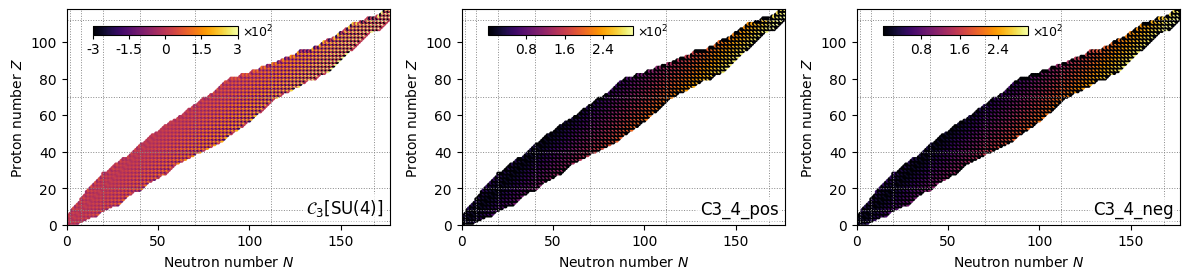

<Figure size 640x480 with 0 Axes>

In [6]:
# Split the signed SU(4) cubic Casimir into two nonnegative branches.
# A zero means that sign branch is inactive for that nucleus.
df["C3_4_pos"] = df["C3_4"].clip(lower=0)
df["C3_4_neg"] = (-df["C3_4"]).clip(lower=0)

# sanity check: the two branches reconstruct the signed Casimir exactly
assert (df["C3_4_pos"] - df["C3_4_neg"]).equals(df["C3_4"])

symass.plot_maps(df, ["C3_4", "C3_4_pos", "C3_4_neg"], cmap="inferno", figsize=(12, 6), title_out=False,
                 savefig="figures/C3_4_split.png")
plt.tight_layout()
plt.show()

## 3 — Correlation matrix

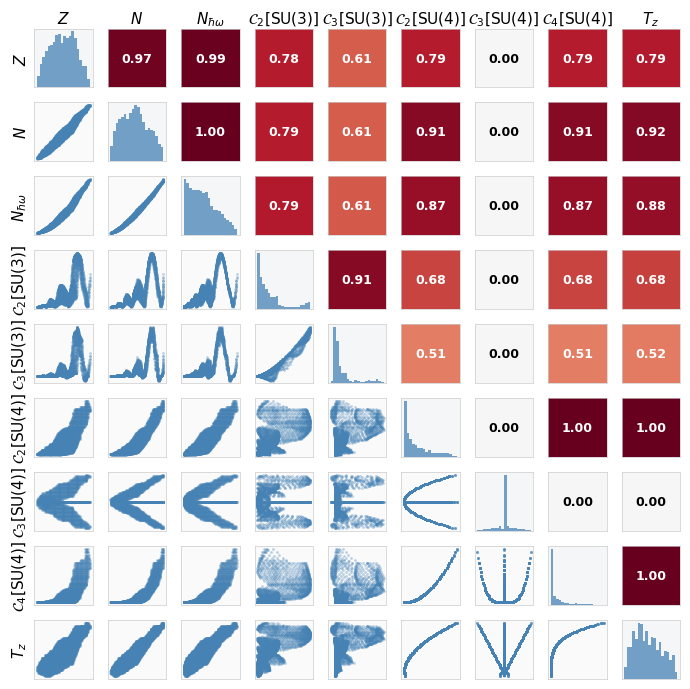

In [7]:
symass.plot_correlations(X, FEATURES, scatter=True, figsize=(7,7), method="spearman")
plt.show()

## 4 — Maximal Information Coefficient (MIC)

Spearman *r* is a powerful baseline, but it only detects **monotone** relationships.
Most feature pairs have non-monotone functional dependencies — for
example, C3[SU(3)] is an odd function of the quantum numbers and can be negatively
correlated with C2[SU(4)] in one half of the chart and positively in the other, giving
a Spearman *r* zero despite a strong functional relationship.

**MIC** (Maximal Information Coefficient, Reshef et al. *Science* 2011) addresses this
by asking: *what is the maximum mutual information achievable by any grid partition of
the data?*  It is normalised to [0, 1] and detects any functional relationship — linear,
polynomial, periodic, or arbitrary — without specifying it in advance.

| Property | Spearman *r* | MIC |
|---|---|---|
| Range | [−1, 1] | [0, 1] |
| Detects direction | Yes (sign) | No |
| Detects non-monotone dependence | No | Yes |
| Independence → 0 | Yes | Yes |
| Perfect noiseless relation → max | ±1 | 1 |
| Computational cost | O(n log n) | O(n log² n) |

The two metrics are complementary:
- High Spearman, high MIC → strong **monotone** relationship
- Low Spearman, high MIC → strong **non-monotone** relationship (potentially
  the most interesting case — the features are functionally linked but the
  link is not captured by linear or rank correlation)
- Low Spearman, low MIC → genuinely independent features


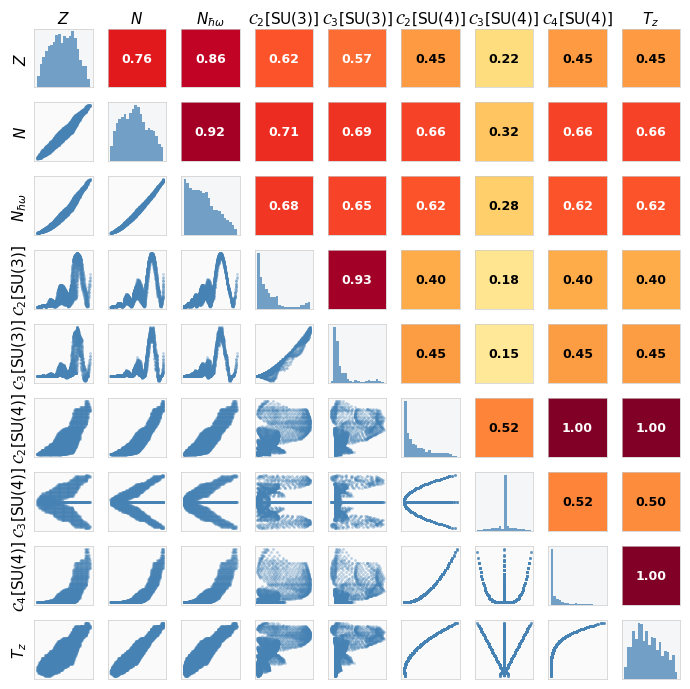

In [5]:
# MIC matrix — detects any functional relationship, not just monotone ones.
# Uses pstats() from minepy, which expects (n_vars, n_samples).
# alpha=0.6, c=15 are the standard defaults from Reshef et al. (2011).
symass.plot_correlations(X, FEATURES, method="mic", scatter=True, figsize=(7, 7), savefig="figures/SU3SU4_correlations.png")
plt.show()

## 5 — Dataset summary


In [6]:
print(f"{'Feature':<12} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10}")
print("-" * 54)
for i, feat in enumerate(FEATURES):
    col = X[:, i]
    print(f"{feat:<12} {col.min():>10.4f} {col.max():>10.4f} {col.mean():>10.4f} {col.std():>10.4f}")

Feature             Min        Max       Mean        Std
------------------------------------------------------
Z                0.0000   118.0000    57.9680    28.0286
N                0.0000   177.0000    82.4429    43.6727
Nhw              0.0000  1275.0000   470.3269   321.1570
C2_3             0.0000 10426.0000  2657.7334  2844.3069
C3_3         -22950.0000 232322.2188 35426.8828 57473.7930
C2_4             0.0000  2310.0000   561.5908   573.8212
C3_4          -301.5000   301.5000     0.2201   107.0315
C4_4             0.0000 341591.2500 41838.5977 67222.0078
T_z             -4.0000    32.0000    12.2375     8.9293


## 6 — Functional form of the SU(4) Casimirs in $T_z$

The correlation analysis showed that the even SU(4) Casimirs, $\mathcal{C}_2[\mathrm{SU}(4)]$ and
$\mathcal{C}_4[\mathrm{SU}(4)]$, are perfectly correlated with the isospin projection
$T_z=(N-Z)/2$ (MIC$=1.00$): for the dominant lowest-$\mathcal{C}_2$ irrep they reduce to smooth
functions of $T_z$. Here we recover that functional form. The eigenvalues are **even** in $T_z$
(they depend on $|N-Z|$), so we fit polynomials in $|T_z| = |N-Z|/2$ — a quadratic for
$\mathcal{C}_2$ and a quartic for $\mathcal{C}_4$, mirroring the second- and fourth-order Casimir
structure.

C2/C4 even in T_z (values match at +/-|T_z|): True

Detected functional forms (polynomials in |T_z|):
  C2[SU(4)] = +2.001*|T_z|^2 +7.971*|T_z|^1 +3.195*|T_z|^0    R^2 = 0.999985
  C4[SU(4)] = +0.2517*|T_z|^4 +1.904*|T_z|^3 +11.91*|T_z|^2 +15.46*|T_z|^1 +22.85*|T_z|^0    R^2 = 0.999908


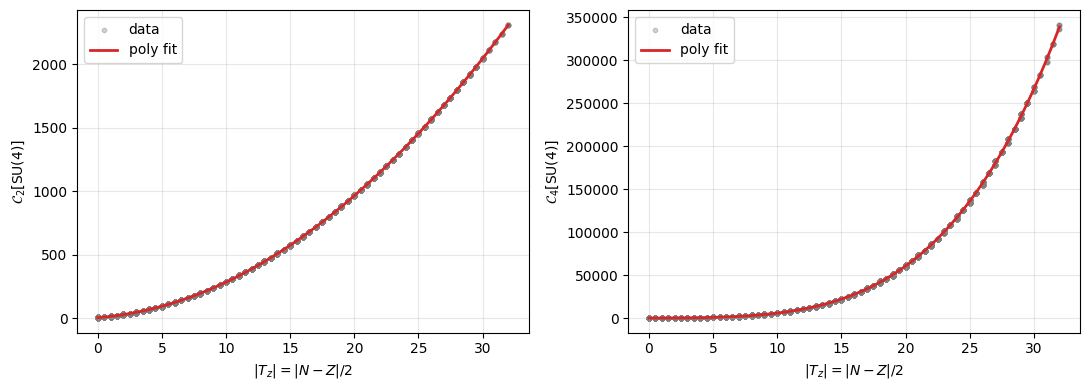

In [8]:
import numpy as np

tz = df["T_z"].to_numpy(float)
c2 = df["C2_4"].to_numpy(float)
c4 = df["C4_4"].to_numpy(float)
m  = np.abs(tz)                       # |T_z| = |N-Z|/2  (the natural, even variable)

def r2(y, p):
    return 1.0 - np.sum((y - p) ** 2) / np.sum((y - y.mean()) ** 2)

# evenness check: C2/C4 at +/- the same |T_z| coincide
even_ok = all(
    np.allclose(c2[np.isclose(tz, t)][:1], c2[np.isclose(tz, -t)][:1])
    for t in (0.5, 1, 1.5, 2, 3, 4)
    if np.isclose(tz, t).any() and np.isclose(tz, -t).any()
)
print(f"C2/C4 even in T_z (values match at +/-|T_z|): {even_ok}\n")

# polynomial fits in |T_z|
p2 = np.polyfit(m, c2, 2)             # C2 ~ quadratic
p4 = np.polyfit(m, c4, 4)             # C4 ~ quartic

def show(name, coef, var="|T_z|"):
    deg = len(coef) - 1
    terms = " ".join(f"{c:+.4g}*{var}^{deg - i}" for i, c in enumerate(coef))
    return f"{name} = {terms}"

print("Detected functional forms (polynomials in |T_z|):")
print(" ", show("C2[SU(4)]", p2), f"   R^2 = {r2(c2, np.polyval(p2, m)):.6f}")
print(" ", show("C4[SU(4)]", p4), f"   R^2 = {r2(c4, np.polyval(p4, m)):.6f}")

# data + fitted curve
grid = np.linspace(0, m.max(), 400)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, yv, name, p in [(ax[0], c2, r"$\mathcal{C}_2[\mathrm{SU(4)}]$", p2),
                       (ax[1], c4, r"$\mathcal{C}_4[\mathrm{SU(4)}]$", p4)]:
    a.scatter(m, yv, s=10, alpha=0.35, color="tab:gray", label="data")
    a.plot(grid, np.polyval(p, grid), color="tab:red", lw=2, label="poly fit")
    a.set_xlabel(r"$|T_z| = |N-Z|/2$"); a.set_ylabel(name)
    a.legend(); a.grid(alpha=0.3)
#fig.suptitle(r"SU(4) Casimirs as polynomials of $|T_z|$ (leading irrep)", y=1.02)
fig.tight_layout()
fig.savefig("figures/su4_casimir_tz_fit.png", dpi=200, bbox_inches="tight")
plt.show()